# Code for analysing party program data

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import matplotx

In [3]:
df = pd.read_csv('party_programs_classified.csv', index_col=0)
df

,party,year,body,ai_related,matched_keywords_title,matched_keywords_body,matched_keywords_all,n_hits_title_total,n_hits_body_total
0,BIJ1,2025,Doe eerlijk. Doe eerlijk. STEM Tweede Kamer ve...,no,[],['ai'],['ai'],0,1
1,50PLUS,2025,Verkiezingsprogramma 2025 - 2029 1 Verkiezings...,yes,[],"['ai', 'artificiële intelligentie', 'kunstmati...","['ai', 'artificiële intelligentie', 'kunstmati...",0,4
2,50PLUS,2019,1 Onze toekomst in Europa. Solidair met jong e...,no,[],[],[],0,0
3,GroenLinks,2019,Resolution: Freedom opportunity prosperity: th...,yes,[],['artificial intelligence'],['artificial intelligence'],0,2
4,DENK,2018,LIJST 1 SAMEN MAKEN WIJ ER WERK VAN Vooraf Eco...,no,[],[],[],0,0
...,...,...,...,...,...,...,...,...,...
211,DENK,2025,1 VRIJ VERBOND VERKIEZINGS- PROGRAMMA 2025 – 2...,no,[],[],[],0,0
212,VVD,2019,PROGRAMMACOMMISSIE Ruben Brekelmans Debbie van...,yes,[],['kunstmatige intelligentie'],['kunstmatige intelligentie'],0,6
213,DENK,2017,Concept verkiezingsprogramma 2017-2021 ZEKER N...,no,[],[],[],0,0
214,DENK,2017,VVD verkiezingsprogramma 2017-2021 ZEKER NEDER...,no,[],['kunstmatige intelligentie'],['kunstmatige intelligentie'],0,1


In [4]:
# keep ai related programs only
df_ai_only = df[df['ai_related'] == 'yes']
df_ai_only

,party,year,body,ai_related,matched_keywords_title,matched_keywords_body,matched_keywords_all,n_hits_title_total,n_hits_body_total
1,50PLUS,2025,Verkiezingsprogramma 2025 - 2029 1 Verkiezings...,yes,[],"['ai', 'artificiële intelligentie', 'kunstmati...","['ai', 'artificiële intelligentie', 'kunstmati...",0,4
3,GroenLinks,2019,Resolution: Freedom opportunity prosperity: th...,yes,[],['artificial intelligence'],['artificial intelligence'],0,2
7,BBB,2023,Visie en Verkiezingsprogramma 2023-2027 Van Ve...,yes,[],"['ai', 'artificial intelligence', 'kunstmatige...","['ai', 'artificial intelligence', 'kunstmatige...",0,8
8,BBB,2024,SAMENVATTING BBB VERKIEZINGSPROGRAMMA EUROPEES...,yes,[],['kunstmatige intelligentie'],['kunstmatige intelligentie'],0,2
9,BBB,2024,BBB VERKIEZINGSPROGRAMMA EUROPEES PARLEMENT 20...,yes,[],"['ai', 'artificial intelligence', 'kunstmatige...","['ai', 'artificial intelligence', 'kunstmatige...",0,12
...,...,...,...,...,...,...,...,...,...
203,Volt,2018,Volt’s programme for the European Parliament 2...,yes,[],"['ai', 'artificial intelligence']","['ai', 'artificial intelligence']",0,22
204,Volt,2019,Volt’s programme for the European Parliament 2...,yes,[],"['ai', 'artificial intelligence']","['ai', 'artificial intelligence']",0,9
205,Volt,2024,Het programma van Volt voor het Europees Parle...,yes,[],['kunstmatige intelligentie'],['kunstmatige intelligentie'],0,4
206,Volt,2025,VERKIEZINGSPROGRAMMA Volt Nederland 1 Verkiezi...,yes,[],"['ai', 'chatgpt', 'generatieve ai', 'gpt', 'ku...","['ai', 'chatgpt', 'generatieve ai', 'gpt', 'ku...",0,71


In [5]:
# How many programs
len(df)

216

In [6]:
df['year'].value_counts()

year
2017    57
2018    42
2025    36
2019    25
2021    25
2024    17
2023    13
2020     1
Name: count, dtype: int64

### (Use this to change wrong dates)

In [52]:
# print body of specific program search by year
df['body'].iloc[29]


'PRO GRAMMA 2023 BREEK DE KETENS ‘Laten we BIJ1 komen om een wereld te creëren waarin vrijheid niet langer een abstract begrip is maar een tastbare realiteit voor eenieder.’ Edson Olf BEKEN KLEUR VOORWOORD EDSON OLF Elke ochtend nog voordat de zon haar eerste stralen over Rotterdam wierp stond mijn moeder om 5 uur op om naar haar werk te gaan. Haar dag begon vroeg veel vroeger dan die van de meeste mensen. Een vrouw van vele facetten. Zorgzaam liefdevol maar ook streng. Thuis wisten we altijd EXACT waar we aan toe waren als wij iets deden dat niet mocht. Ik kan me de dag nog goed herinneren toen ze tegen mij zei dat mensen zoals wij in dit land 2 of 3 keer harder moeten werken om misschien als álles meezit misschien hetzelfde te bereiken. Het bracht een wirwar van emoties teweeg. Angst. Verdriet. Machteloosheid. Maar ook strijdbaarheid. Ik zie in dat we ondanks de ONvrijheden die we tegenkomen moeten blijven vechten voor een rechtvaardigere wereld. Een wereld waarin iedereen wordt geac

In [53]:
# print the title for specific year
df[df['year'] == 2027]['body']
# change it to 2017
df.loc[df['year'] == 2027, 'year'] = 2023


### Analysis

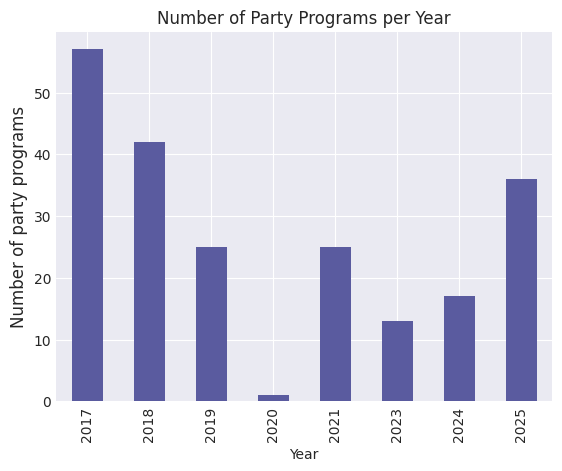

In [8]:
# what years are covered
df['year'].value_counts().sort_index()

plt.style.use(matplotx.styles.pacoty)

# plot number of programs per year
import matplotlib.pyplot as plt
df['year'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Year')
plt.ylabel('Number of party programs', fontsize=12)
plt.title('Number of Party Programs per Year')
plt.show()

In [9]:
# how many rows are ai_related == True
df['ai_related'].value_counts()


ai_related
no     153
yes     63
Name: count, dtype: int64

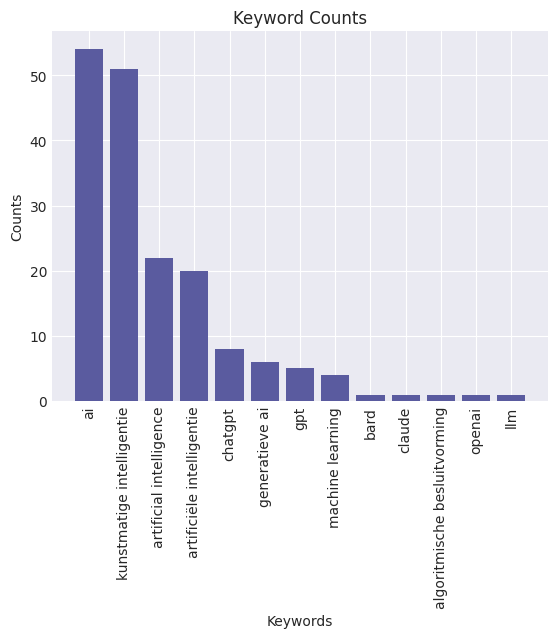

In [10]:
# what keywords are matched
df['matched_keywords_all'].value_counts()
# eclude '[]' entries
df_no_brackets = df[df['matched_keywords_all'] != '[]']

# # count unique keywords
# unique_keywords = set()
# for keywords in df_no_brackets['matched_keywords_all']:
#     # remove brackets and split by comma
#     keywords_list = keywords.strip('[]').replace("'", "").split(', ')
#     unique_keywords.update(keywords_list)
# print(f'Unique keywords: {unique_keywords}')

# plot keywords list
keyword_counts = {}
for keywords in df_no_brackets['matched_keywords_all']:
    keywords_list = keywords.strip('[]').replace("'", "").split(', ')
    for keyword in keywords_list:
        if keyword in keyword_counts:
            keyword_counts[keyword] += 1
        else:
            keyword_counts[keyword] = 1
# sort by count
sorted_keyword_counts = dict(sorted(keyword_counts.items(), key=lambda item: item[1], reverse
=True))
# plot
plt.style.use(matplotx.styles.pacoty)
plt.bar(sorted_keyword_counts.keys(), sorted_keyword_counts.values())
plt.xticks(rotation=90)
plt.xlabel('Keywords')
plt.ylabel('Counts')
plt.title('Keyword Counts')
plt.show()

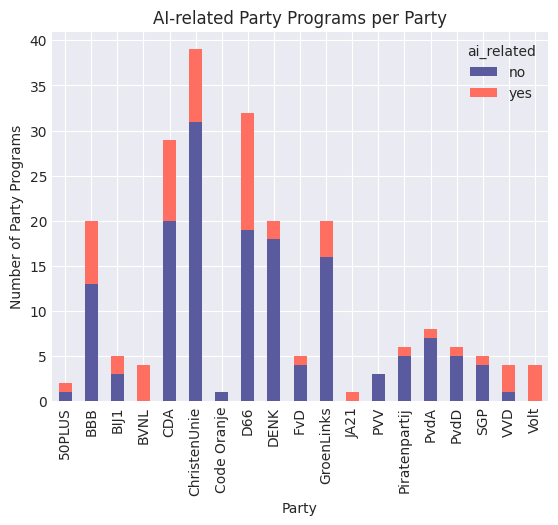

In [11]:
# ai mentions per party
df['ai_related'].groupby(df['party']).value_counts().unstack().fillna(0).plot(kind='bar', stacked=True)
plt.style.use(matplotx.styles.pacoty)
plt.xlabel('Party')
plt.ylabel('Number of Party Programs')
plt.title('AI-related Party Programs per Party')
plt.show()



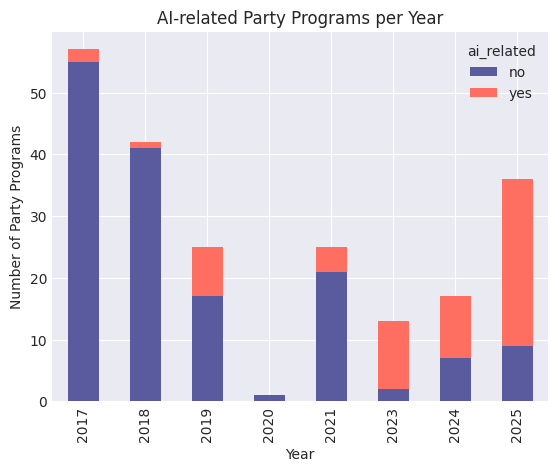

In [12]:
# ai mentions per year
df['ai_related'].groupby(df['year']).value_counts().unstack().fillna(0).plot(kind='bar', stacked=True)
plt.style.use(matplotx.styles.pacoty)
plt.xlabel('Year')
plt.ylabel('Number of Party Programs')
plt.title('AI-related Party Programs per Year')
plt.show()

In [13]:
import re
import ast
import pandas as pd

def _norm_matched_keywords(val):
    """
    Normalize matched_keywords_all into a list[str].
    Accepts: list/set/tuple, stringified list (e.g. "['ai','ml']"),
             or comma-separated string ("ai, machine learning").
    """
    if val is None or (isinstance(val, float) and pd.isna(val)):
        return []
    if isinstance(val, (list, set, tuple)):
        kws = list(val)
    elif isinstance(val, str):
        s = val.strip()
        if not s:
            return []
        # Try to parse stringified list
        try:
            parsed = ast.literal_eval(s)
            if isinstance(parsed, (list, set, tuple)):
                kws = list(parsed)
            else:
                # fallback: treat as comma-separated
                kws = [x.strip() for x in s.split(",") if x.strip()]
        except Exception:
            kws = [x.strip() for x in s.split(",") if x.strip()]
    else:
        return []

    # clean, dedupe, keep phrases
    out = []
    seen = set()
    for k in kws:
        if not isinstance(k, str):
            continue
        k2 = k.strip()
        if not k2:
            continue
        kl = k2.lower()
        if kl not in seen:
            seen.add(kl)
            out.append(k2)
    return out

def _extract_windows(text, keywords, window=5, max_snippets=5):
    """
    Build a plain-text section composed of ±window words around each keyword hit.
    Returns: (section_text, spans, n_matches)
    """
    if not isinstance(text, str) or not text.strip():
        return "", [], 0
    keywords = _norm_matched_keywords(keywords)
    if not keywords:
        return "", [], 0

    # Safer "word boundary" for phrases: (?<!\w) ... (?!\w)
    # (handles multi-word phrases and punctuation better than \b ... \b)
    alts = [re.escape(k) for k in keywords]
    pattern = r'(?<!\w)(?:' + '|'.join(alts) + r')(?!\w)'
    flags = re.IGNORECASE

    matches = list(re.finditer(pattern, text, flags))
    if not matches:
        return "", [], 0

    # Word spans to take ±window words
    word_spans = [(m.start(), m.end()) for m in re.finditer(r'\S+', text)]

    def word_index_for_pos(pos):
        # small linear scan is fine for typical lengths
        for i, (s, e) in enumerate(word_spans):
            if s <= pos < e:
                return i
        # if match starts on whitespace, snap to next word
        for i, (s, e) in enumerate(word_spans):
            if pos < e:
                return i
        return len(word_spans) - 1 if word_spans else 0

    spans = []
    for m in matches:
        wi = word_index_for_pos(m.start())
        start_w = max(0, wi - window)
        end_w   = min(len(word_spans), wi + window + 1)
        start_c = word_spans[start_w][0]
        end_c   = word_spans[end_w - 1][1]

        if spans and start_c <= spans[-1][1]:
            spans[-1] = (spans[-1][0], max(spans[-1][1], end_c))
        else:
            spans.append((start_c, end_c))

    spans = spans[:max_snippets]

    parts = []
    for i, (s, e) in enumerate(spans):
        prefix = '...' if (i == 0 and s > 0) else ''
        suffix = '...' if (i == len(spans)-1 and e < len(text)) else ''
        parts.append(prefix + text[s:e].strip() + suffix)

    section_text = ' '.join(parts)
    return section_text, spans, len(matches)

def add_relevant_section(df, body_col='body', matched_col='matched_keywords_all',
                         window=5, max_snippets=5):
    """
    Adds:
      - relevant_section (plain text)
      - relevant_section_spans (char spans)
      - n_keyword_matches
      - relevant_len_chars
      - relevant_len_words
    """
    results = df.apply(
        lambda r: _extract_windows(
            str(r[body_col]) if pd.notna(r.get(body_col)) else "",
            r.get(matched_col),
            window,
            max_snippets
        ),
        axis=1
    )
    df['relevant_section']       = results.map(lambda t: t[0])
    df['relevant_section_spans'] = results.map(lambda t: t[1])
    df['n_keyword_matches']      = results.map(lambda t: t[2])
    df['relevant_len_chars']     = df['relevant_section'].str.len()
    df['relevant_len_words']     = df['relevant_section'].str.count(r'\b\w+\b')
    return df


In [14]:
df_relevant = add_relevant_section(df, body_col='body', matched_col='matched_keywords_all', window=20)
df_relevant

,party,year,body,ai_related,matched_keywords_title,matched_keywords_body,matched_keywords_all,n_hits_title_total,n_hits_body_total,relevant_section,relevant_section_spans,n_keyword_matches,relevant_len_chars,relevant_len_words
0,BIJ1,2025,Doe eerlijk. Doe eerlijk. STEM Tweede Kamer ve...,no,[],['ai'],['ai'],0,1,...kennis in de wapenindustrie voor de civiele...,"[(80246, 80522)]",1,282,41
1,50PLUS,2025,Verkiezingsprogramma 2025 - 2029 1 Verkiezings...,yes,[],"['ai', 'artificiële intelligentie', 'kunstmati...","['ai', 'artificiële intelligentie', 'kunstmati...",0,4,...met specifieke aandacht voor internetgebrui...,"[(15118, 15544), (22237, 22511)]",5,707,96
2,50PLUS,2019,1 Onze toekomst in Europa. Solidair met jong e...,no,[],[],[],0,0,,[],0,0,0
3,GroenLinks,2019,Resolution: Freedom opportunity prosperity: th...,yes,[],['artificial intelligence'],['artificial intelligence'],0,2,...judicial independence and freedom of the pr...,"[(5703, 6007), (22976, 23224)]",2,559,82
4,DENK,2018,LIJST 1 SAMEN MAKEN WIJ ER WERK VAN Vooraf Eco...,no,[],[],[],0,0,,[],0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,DENK,2025,1 VRIJ VERBOND VERKIEZINGS- PROGRAMMA 2025 – 2...,no,[],[],[],0,0,,[],0,0,0
212,VVD,2019,PROGRAMMACOMMISSIE Ruben Brekelmans Debbie van...,yes,[],['kunstmatige intelligentie'],['kunstmatige intelligentie'],0,6,...Ambitieus doel voor CO2- reductie op Europe...,"[(1703, 2022), (8303, 8604), (23626, 23925), (...",6,1532,208
213,DENK,2017,Concept verkiezingsprogramma 2017-2021 ZEKER N...,no,[],[],[],0,0,,[],0,0,0
214,DENK,2017,VVD verkiezingsprogramma 2017-2021 ZEKER NEDER...,no,[],['kunstmatige intelligentie'],['kunstmatige intelligentie'],0,1,...vrijheden. En dat die waarden niet onderhan...,"[(20796, 21095)]",1,305,41


In [15]:
# add total word count of body column
df_relevant['total_len_words'] = df_relevant['body'].str.count(r'\b\w+\b')

In [16]:
#only keep relevant rows
df_relevant_only = df_relevant[df_relevant['ai_related'] == 'yes']
df_relevant_only

,party,year,body,ai_related,matched_keywords_title,matched_keywords_body,matched_keywords_all,n_hits_title_total,n_hits_body_total,relevant_section,relevant_section_spans,n_keyword_matches,relevant_len_chars,relevant_len_words,total_len_words
1,50PLUS,2025,Verkiezingsprogramma 2025 - 2029 1 Verkiezings...,yes,[],"['ai', 'artificiële intelligentie', 'kunstmati...","['ai', 'artificiële intelligentie', 'kunstmati...",0,4,...met specifieke aandacht voor internetgebrui...,"[(15118, 15544), (22237, 22511)]",5,707,96,4169
3,GroenLinks,2019,Resolution: Freedom opportunity prosperity: th...,yes,[],['artificial intelligence'],['artificial intelligence'],0,2,...judicial independence and freedom of the pr...,"[(5703, 6007), (22976, 23224)]",2,559,82,5773
7,BBB,2023,Visie en Verkiezingsprogramma 2023-2027 Van Ve...,yes,[],"['ai', 'artificial intelligence', 'kunstmatige...","['ai', 'artificial intelligence', 'kunstmatige...",0,8,...zowel aan docenten als aan leerlingen gegev...,"[(337909, 338171), (357517, 357828), (358520, ...",8,1426,207,91202
8,BBB,2024,SAMENVATTING BBB VERKIEZINGSPROGRAMMA EUROPEES...,yes,[],['kunstmatige intelligentie'],['kunstmatige intelligentie'],0,2,...voor onderzoek breder inzetten en het MKB e...,"[(10854, 11200)]",2,352,49,3798
9,BBB,2024,BBB VERKIEZINGSPROGRAMMA EUROPEES PARLEMENT 20...,yes,[],"['ai', 'artificial intelligence', 'kunstmatige...","['ai', 'artificial intelligence', 'kunstmatige...",0,12,...noodzakelijke investeringen kunnen doen maa...,"[(68064, 69007), (69027, 69406), (91475, 91731...",13,1890,280,23619
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,Volt,2018,Volt’s programme for the European Parliament 2...,yes,[],"['ai', 'artificial intelligence']","['ai', 'artificial intelligence']",0,22,...and ESF+. Boost entrepreneurship and the cr...,"[(75235, 75513), (80945, 81210), (84265, 85353...",22,2657,434,23250
204,Volt,2019,Volt’s programme for the European Parliament 2...,yes,[],"['ai', 'artificial intelligence']","['ai', 'artificial intelligence']",0,9,...> Boost entrepreneurship and the creation o...,"[(11711, 11985), (12275, 12533), (12647, 13394)]",9,1287,202,3582
205,Volt,2024,Het programma van Volt voor het Europees Parle...,yes,[],['kunstmatige intelligentie'],['kunstmatige intelligentie'],0,4,...EU worden vereenvoudigd. > Stimuleer ondern...,"[(12829, 13142), (13443, 13729), (13951, 14451)]",4,1107,154,3718
206,Volt,2025,VERKIEZINGSPROGRAMMA Volt Nederland 1 Verkiezi...,yes,[],"['ai', 'chatgpt', 'generatieve ai', 'gpt', 'ku...","['ai', 'chatgpt', 'generatieve ai', 'gpt', 'ku...",0,71,...elkaar laat spelen verstopt Nederland zich ...,"[(975, 1225), (2936, 3216), (9695, 9935), (100...",77,1392,212,57568


In [17]:
# make sure matched_keywords_all is list
for idx, row in df_relevant_only.iterrows():
    if isinstance(row['matched_keywords_all'], str):
        try:
            df_relevant_only.at[idx, 'matched_keywords_all'] = ast.literal_eval(row['matched_keywords_all'])
        except (ValueError, SyntaxError):
            df_relevant_only.at[idx, 'matched_keywords_all'] = []
df_relevant_only['matched_keywords_all'].iloc[1]

['artificial intelligence']

### Inspect examples

In [18]:
import re
import pandas as pd
from html import escape
from IPython.display import display, HTML

def inspect_ai_related(df, num_samples=30, random_state=42):
    """
    Displays random samples with highlighted *matched* keywords.
    Uses df['matched_keywords_all'] per row instead of a global keyword list.
    Works even if 'title' column is missing.
    """

    # --- sanity checks ---
    if 'ai_related' not in df.columns:
        raise KeyError("DataFrame must contain an 'ai_related' column.")
    if 'body' not in df.columns:
        raise KeyError("DataFrame must contain a 'body' column.")
    if 'matched_keywords_all' not in df.columns:
        raise KeyError("DataFrame must contain 'matched_keywords_all'.")

    # --- sample ---
    n = min(num_samples, len(df))
    samples = df.sample(n=n, random_state=random_state)

    # --- internal highlight function ---
    def highlight_keywords(text, keywords):
        if pd.isna(text):
            return ""
        s = str(text)

        if not isinstance(keywords, (set, list)):
            raise ValueError("Keywords must be a set or list")
        kws = {str(w).strip().lower() for w in keywords if str(w).strip()}
        if not kws:
            return s

        # sort by length to avoid partial overshadowing
        ordered = sorted(kws, key=len, reverse=True)

        # custom boundary: match even inside hyphenated words
        def make_pattern(word):
            return rf'(?<![A-Za-z0-9]){re.escape(word)}(?![A-Za-z0-9])'

        combined = "|".join(make_pattern(w) for w in ordered)
        regex = re.compile(combined, flags=re.IGNORECASE)

        def repl(m):
            kw = m.group(0)
            return f'<span style="font-size:1.5em; font-weight:bold; color:green;">{escape(kw)}</span>'

        return regex.sub(repl, s)

    # --- display samples ---
    for idx, row in samples.iterrows():
        ai_val = row['ai_related']
        body   = row['relevant_section']
        title  = row.get('title', None)

        # --- use the actually matched keywords in this row ---
        matched_keywords = row.get('matched_keywords_all', [])
        if isinstance(matched_keywords, (list, set, tuple)):
            row_terms = {str(x).lower() for x in matched_keywords}
        else:
            row_terms = {str(matched_keywords).lower()} if matched_keywords else set()

        # --- highlight ---
        highlighted_body  = highlight_keywords(body, row_terms)
        highlighted_title = highlight_keywords(title, row_terms) if title is not None else None

        # --- header ---
        header_html = (
            f'<div style="margin:0.5em 0;">'
            f'<strong>Index:</strong> {idx} &nbsp; | &nbsp; '
            f'<strong>ai_related:</strong> {ai_val}'
        )
        if matched_keywords:
            header_html += f'<br><strong>matched keywords:</strong> {matched_keywords}'
        header_html += '</div>'

        # --- display ---
        display(HTML(header_html))
        if highlighted_title:
            display(HTML(f'<h3 style="margin:0.2em 0;">{highlighted_title}</h3>'))
        display(HTML(f'<div style="line-height:1.5;">{highlighted_body}</div>'))
        display(HTML('<hr>'))

    print(f"Displayed {n} random articles (with row-specific matched keywords highlighted).")
    return samples

In [19]:
inspect_ai_related(df_relevant_only, num_samples=5)

Displayed 5 random articles (with row-specific matched keywords highlighted).


,party,year,body,ai_related,matched_keywords_title,matched_keywords_body,matched_keywords_all,n_hits_title_total,n_hits_body_total,relevant_section,relevant_section_spans,n_keyword_matches,relevant_len_chars,relevant_len_words,total_len_words
206,Volt,2025,VERKIEZINGSPROGRAMMA Volt Nederland 1 Verkiezi...,yes,[],"['ai', 'chatgpt', 'generatieve ai', 'gpt', 'ku...","[ai, chatgpt, generatieve ai, gpt, kunstmatige...",0,71,...elkaar laat spelen verstopt Nederland zich ...,"[(975, 1225), (2936, 3216), (9695, 9935), (100...",77,1392,212,57568
202,VVD,2025,1 Sterker uit de storm Keuzes voor een nieuwe ...,yes,[],"['ai', 'artificiële intelligentie', 'kunstmati...","[ai, artificiële intelligentie, kunstmatige in...",0,24,...is gericht op start- en scale-ups zodat zij...,"[(8539, 8789), (10322, 10579), (12740, 13038),...",24,1973,300,40350
1,50PLUS,2025,Verkiezingsprogramma 2025 - 2029 1 Verkiezings...,yes,[],"['ai', 'artificiële intelligentie', 'kunstmati...","[ai, artificiële intelligentie, kunstmatige in...",0,4,...met specifieke aandacht voor internetgebrui...,"[(15118, 15544), (22237, 22511)]",5,707,96,4169
129,D66,2017,1 D66 Verkiezingsprogramma 2017-2021 December ...,yes,[],['artificiële intelligentie'],[artificiële intelligentie],0,3,...komende jaren aangesloten op internet en ku...,"[(179720, 180030), (185161, 185470), (188953, ...",3,939,125,66102
12,BBB,2023,Visie en Verkiezingsprogramma 2023-2027 Van Ve...,yes,[],"['ai', 'artificial intelligence', 'kunstmatige...","[ai, artificial intelligence, kunstmatige inte...",0,5,...moet zowel aan docenten als aan leerlingen ...,"[(190282, 190548), (200721, 201032), (201725, ...",5,1473,206,47281


In [20]:
df_relevant_only_clean = df_relevant_only.drop(columns=['matched_keywords_title', 'matched_keywords_body', 'n_hits_title_total', 'relevant_section_spans', 'n_keyword_matches', 'relevant_len_chars'])

In [21]:
df_relevant_only_clean = df_relevant_only_clean.drop(columns=['ai_related'])

In [22]:
# rename relevant_section to ai_relevant_section
df_relevant_only_clean = df_relevant_only_clean.rename(columns={'relevant_section': 'body'})

In [119]:
df_relevant_only_clean.to_csv('party_programs_ai_relevant_sections.csv')

In [23]:
df_relevant_only_clean.head()

,party,year,body,matched_keywords_all,n_hits_body_total,body,relevant_len_words,total_len_words
1,50PLUS,2025,Verkiezingsprogramma 2025 - 2029 1 Verkiezings...,"[ai, artificiële intelligentie, kunstmatige in...",4,...met specifieke aandacht voor internetgebrui...,96,4169
3,GroenLinks,2019,Resolution: Freedom opportunity prosperity: th...,[artificial intelligence],2,...judicial independence and freedom of the pr...,82,5773
7,BBB,2023,Visie en Verkiezingsprogramma 2023-2027 Van Ve...,"[ai, artificial intelligence, kunstmatige inte...",8,...zowel aan docenten als aan leerlingen gegev...,207,91202
8,BBB,2024,SAMENVATTING BBB VERKIEZINGSPROGRAMMA EUROPEES...,[kunstmatige intelligentie],2,...voor onderzoek breder inzetten en het MKB e...,49,3798
9,BBB,2024,BBB VERKIEZINGSPROGRAMMA EUROPEES PARLEMENT 20...,"[ai, artificial intelligence, kunstmatige inte...",12,...noodzakelijke investeringen kunnen doen maa...,280,23619


In [24]:
# average words in relevant sections
df_relevant_only['relevant_len_words'].mean()

np.float64(202.68253968253967)

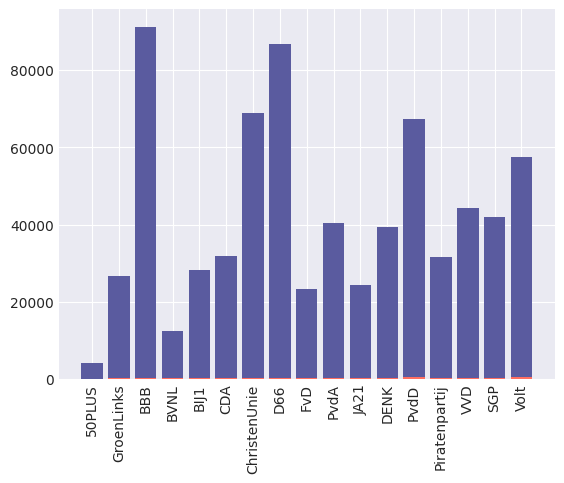

In [25]:
# show barplot relevant vs total word count
plt.style.use(matplotx.styles.pacoty)
plt.bar(df_relevant_only['party'], df_relevant_only['total_len_words'], label='Total Words')
plt.bar(df_relevant_only['party'], df_relevant_only['relevant_len_words'], label='Relevant Words')
plt.xticks(rotation=90)
plt.show()



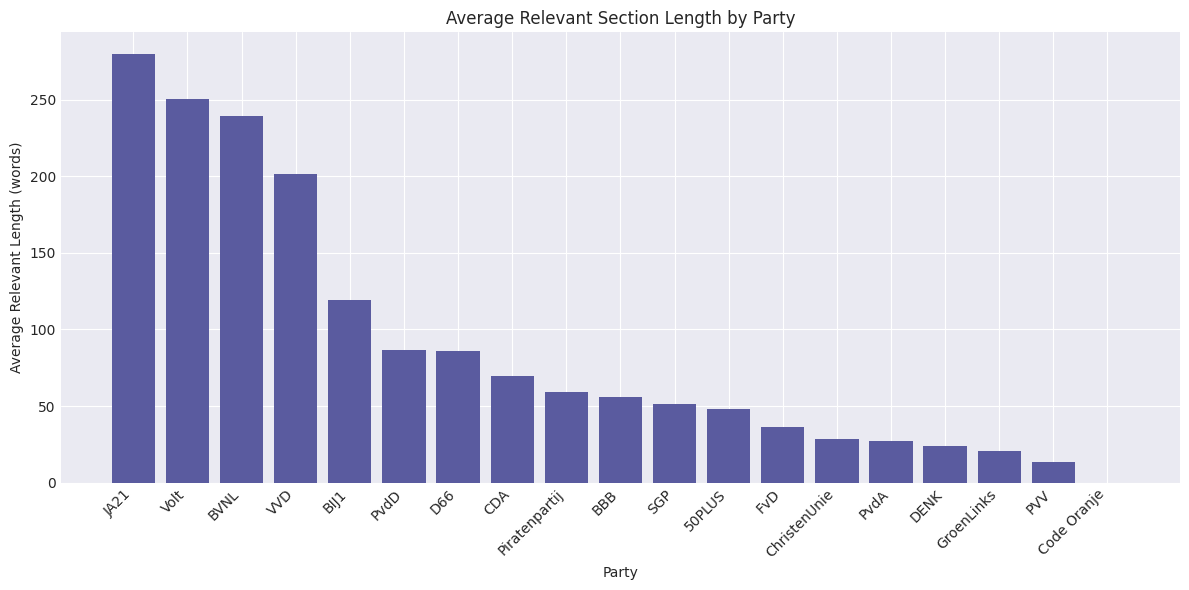

In [26]:
length_by_party = (
    df.groupby('party')['relevant_len_words']
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

length_by_party


plt.style.use(matplotx.styles.pacoty)
plt.figure(figsize=(12,6))  # make the plot wider

plt.bar(length_by_party['party'], length_by_party['relevant_len_words'])

plt.xlabel('Party')
plt.ylabel('Average Relevant Length (words)')
plt.title('Average Relevant Section Length by Party')

plt.xticks(rotation=45, ha='right')  # rotate labels + right-align so they don’t overlap
plt.tight_layout()                  # automatically adjust margins

plt.show()